In [11]:
import numpy as np
import matplotlib.pyplot as plt
dt, n_steps = 0.005, 50
E_trial = -6.6813682880
tau_per_block = dt * n_steps         
n_eql = 50
E_final_cpmcp = -6.808370430045 
E_error_cpmp = 1.162899e-03
eql_block = np.array([0, 10, 20, 30, 40, 50])
tau_eql = eql_block * tau_per_block   # 0, 2.5, ..., 12.5
E_eql = np.array([-6.7474974605, -6.7883754802, -6.8056501146,
                  -6.7984584571, -6.8034075290, -6.8155625150])
W_eql = np.array([4.000000e+02, 4.006057e+02, 4.003720e+02,
                  4.000596e+02, 4.001076e+02, 4.002040e+02])

blk = np.arange(50, 501, 50)
tau_blk = (n_eql + blk) * tau_per_block   # 25, 37.5, ..., 137.5
E_avg = np.array([-6.8090467610, -6.8046702278, -6.8063748739, -6.8066726767, -6.8071119214,
                  -6.8080869825, -6.8076769398, -6.8082885463, -6.8084526794, -6.8083704300])
E_err = np.array([4.739e-03, 3.434e-03, 2.979e-03, 2.253e-03, 1.809e-03,
                  1.658e-03, 1.444e-03, 1.472e-03, 1.308e-03, 1.163e-03])
E_block = np.array([-6.8090467610, -6.8002941302, -6.8097839933, -6.8075660707, -6.8088689357,
                    -6.8129618859, -6.8052165589, -6.8125697118, -6.8097656113, -6.8076301407])
W_blk = np.array([3.999809e+02, 4.000207e+02, 4.000210e+02, 4.000141e+02, 4.000011e+02,
                  4.000406e+02, 3.999928e+02, 4.000177e+02, 4.000516e+02, 3.999914e+02])

# DMRG references for the same lattice (4x4 open/open, U=8, (8,8)), mps_cpmc_2d.py dmrg, 2026-09-30:
# bond dimension -> (energy, discarded weight)
dmrg_ref = {500: (-6.803295, 5.7e-5), 1000: (-6.807745, 1.1e-5), 2000: (-6.808346, 1.2e-6)}
dmrg_extrapolated = (-6.8086, -6.8084)  # extrapolation in discarded weight
E_fci = -6.8084144664  # exact, fci_4x4_hubbard.ipynb (Lanczos, residual 9e-9)

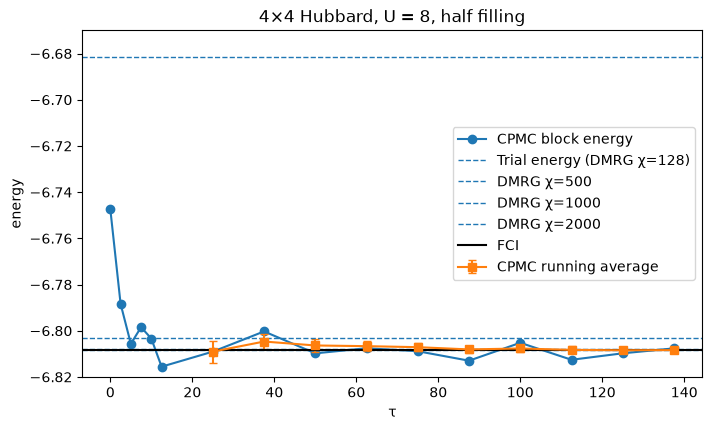

In [12]:
tau_all = np.concatenate([tau_eql, tau_blk])
E_all = np.concatenate([E_eql, E_block])  # equilibration: single printed blocks; sampling: mean of each 50 blocks

plt.figure(figsize=(8, 4.5))
plt.plot(tau_all, E_all, "o-", label="CPMC block energy")
plt.axhline(E_trial, ls="--", lw=1, label=f"Trial energy (DMRG χ=128)")
plt.errorbar(tau_blk, E_avg, yerr=E_err, fmt="s-", capsize=3, label="CPMC running average")
for chi, (energy, discarded) in dmrg_ref.items():
    plt.axhline(energy, ls="--", lw=1, label=f"DMRG χ={chi}")
if E_fci is not None:
    plt.axhline(E_fci, color="k", lw=1.5, label="FCI")
plt.ylim(-6.82, -6.67)
plt.xlabel("τ")
plt.ylabel("energy")
plt.title("4×4 Hubbard, U = 8, half filling")
plt.legend()
plt.show()

In [13]:
# 4x4 Hubbard, U=8, n=0.875 (7,7)
dt, n_steps = 0.005, 50
E_trial = -9.8084528781
tau_per_block = dt * n_steps
n_eql = 50
E_final_cpmcp = -10.0694024275
E_error_cpmp = 1.808e-03
eql_block = np.array([0, 10, 20, 30, 40, 50])
tau_eql = eql_block * tau_per_block
E_eql = np.array([-10.2321031320, -10.0651444104, -10.0664330171,
                  -10.0722595786, -10.0883569710, -10.0764289379])
W_eql = np.array([4.000000e+02, 3.980073e+02, 3.993979e+02,
                  3.999283e+02, 4.002435e+02, 4.000556e+02])

blk = np.arange(50, 501, 50)
tau_blk = (n_eql + blk) * tau_per_block
E_avg = np.array([-10.0655239928, -10.0708898902, -10.0725770784, -10.0717811308, -10.0705119159,
                  -10.0698670864, -10.0690513782, -10.0692385367, -10.0687740607, -10.0694024275])
E_err = np.array([4.174e-03, 5.608e-03, 4.561e-03, 3.168e-03, 2.853e-03,
                  2.490e-03, 2.335e-03, 2.110e-03, 1.913e-03, 1.808e-03])
E_block = np.array([-10.0655239928, -10.0762562646, -10.0759522664, -10.0693917588, -10.0654340529,
                    -10.0666430247, -10.0641563819, -10.0705487879, -10.0650594712, -10.0750578788])
W_blk = np.array([4.004202e+02, 4.003846e+02, 4.003061e+02, 4.001141e+02, 4.002272e+02,
                  4.003011e+02, 4.002311e+02, 4.002402e+02, 4.004094e+02, 4.002821e+02])

# DMRG references (random start, uhf_dmrg_4x4_hubbard.ipynb, 2026-10-06): bond dimension -> energy
dmrg_ref = {500: -10.07637, 1000: -10.112865}
E_fci = -10.1218936956  # exact, 4x4 (7,7) U=8

# UHF-trial CPMC run (same lattice, n_eql = 50, 500 blocks of 50 steps)
E_trial_uhf = -7.72194226  # UHF energy
E_eql_uhf = np.array([-8.7018559702, -9.5647734966, -9.4730506835,
                      -9.4919291971, -9.4626107876, -9.5380158192])
E_avg_uhf = np.array([-9.4645053143, -9.4589135991, -9.4509439516, -9.4540796825, -9.4544145436,
                      -9.4552952475, -9.4535611724, -9.4562095141, -9.4545818684, -9.4543150428])
E_err_uhf = np.array([1.223e-02, 8.779e-03, 7.443e-03, 5.937e-03, 7.127e-03,
                      6.978e-03, 6.698e-03, 6.969e-03, 6.310e-03, 5.712e-03])
E_block_uhf = np.array([-9.4645053143, -9.4533264276, -9.4350108079, -9.4634878423, -9.4557535420,
                        -9.4597009499, -9.4431718887, -9.4747482675, -9.4415622780, -9.4519129161])

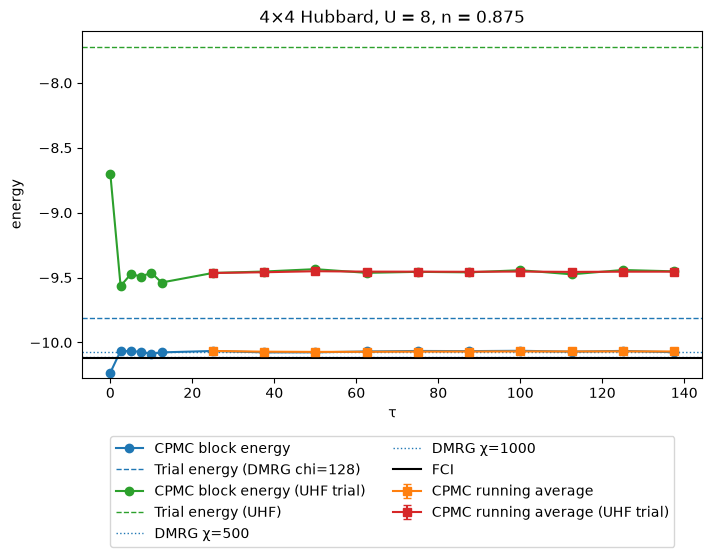

In [15]:
tau_all = np.concatenate([tau_eql, tau_blk])
E_all = np.concatenate([E_eql, E_block])  # equilibration: single printed blocks; sampling: mean of each 50 blocks

plt.figure(figsize=(8, 4.5))
plt.plot(tau_all, E_all, "o-", c="C0", label="CPMC block energy")
plt.axhline(E_trial, ls="--", lw=1, c="C0", label="Trial energy (DMRG chi=128)")
plt.errorbar(tau_blk, E_avg, yerr=E_err, fmt="s-", c="C1", capsize=3, label="CPMC running average")
plt.plot(tau_all, np.concatenate([E_eql_uhf, E_block_uhf]), "o-", c="C2", label="CPMC block energy (UHF trial)")
plt.axhline(E_trial_uhf, ls="--", lw=1, c="C2", label="Trial energy (UHF)")
plt.errorbar(tau_blk, E_avg_uhf, yerr=E_err_uhf, fmt="s-", c="C3", capsize=3, label="CPMC running average (UHF trial)")
for chi, energy in dmrg_ref.items():
    plt.axhline(energy, ls=":", lw=1, label=f"DMRG χ={chi}")
plt.axhline(E_fci, color="k", lw=1.5, label="FCI")
plt.ylim(-10.27, -7.6)
plt.xlabel("τ")
plt.ylabel("energy")
plt.title("4×4 Hubbard, U = 8, n = 0.875")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.show()